In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## 1. Data Loading and Preprocessing
The metro interstate traffic volume dataset is loaded and preprocessed. Missing Values, duplicate records, invalid observations, and data types are examined to ensure the dataset is suitable for time series analysis.

In [36]:
#load dataset
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [37]:
# data cleaning: check shape
print(df.shape)
# check missing values
print(df.isnull().sum())
#check duplicated rows
print(df.duplicated().sum())
#check invalids
print(df[df['traffic_volume']<0])

(48204, 9)
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64
17
Empty DataFrame
Columns: [holiday, temp, rain_1h, snow_1h, clouds_all, weather_main, weather_description, date_time, traffic_volume]
Index: []


In [38]:
# fill holidays
df['holiday'] = df['holiday'].fillna("None")
df['holiday'].value_counts()

holiday
None                         48143
Labor Day                        7
Thanksgiving Day                 6
Christmas Day                    6
New Years Day                    6
Martin Luther King Jr Day        6
Columbus Day                     5
Veterans Day                     5
Washingtons Birthday             5
Memorial Day                     5
Independence Day                 5
State Fair                       5
Name: count, dtype: int64

In [39]:
df =df.drop_duplicates()
print(df.duplicated().sum())

0


In [40]:
#convert 'date_time' to date_time format
df['date_time'] = pd.to_datetime(df['date_time'])
print(df.dtypes)

holiday                        object
temp                          float64
rain_1h                       float64
snow_1h                       float64
clouds_all                      int64
weather_main                   object
weather_description            object
date_time              datetime64[ns]
traffic_volume                  int64
dtype: object


## 2. Exploratory Time Series Analysis
The traffic volume series is visualized to understand its overall behavior. The continuity of the observations, trend, seasonality, and any irregular patterns are examined before model development.
Since a large gap is detected in the dataset, a continuous segment is selected to avoid introducing bias into the forecasting models.

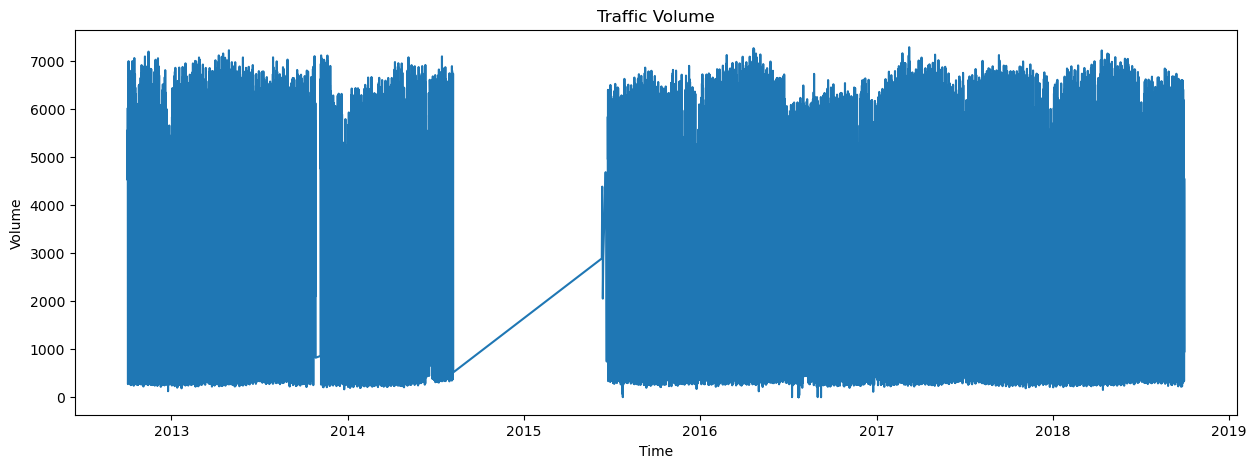

In [41]:
#Visualisation
plt.figure(figsize =(15,5))
plt.plot(df['date_time'],df['traffic_volume'])
plt.title("Traffic Volume")
plt.xlabel("Time")
plt.ylabel("Volume")
plt.show()

In [42]:
# There are long gaps  between 2014 -2015 matplotlib simply joins consecutive points so it appears as a diagonal
#find gaps
gap= df['date_time'].diff()
idx = gap.idxmax()
print(idx)
print(gap.max())
#from 15970 to 15971 their is a gap for 307 days 19hr
#split dataset
df1 = df.iloc[:15971]
df2 = df.iloc[15971:]
print(len(df1))
print(len(df2))


15971
307 days 19:00:00
15971
32216


In [43]:
df = df2.copy()
gap = df['date_time'].diff()
print(gap.max())

4 days 22:00:00


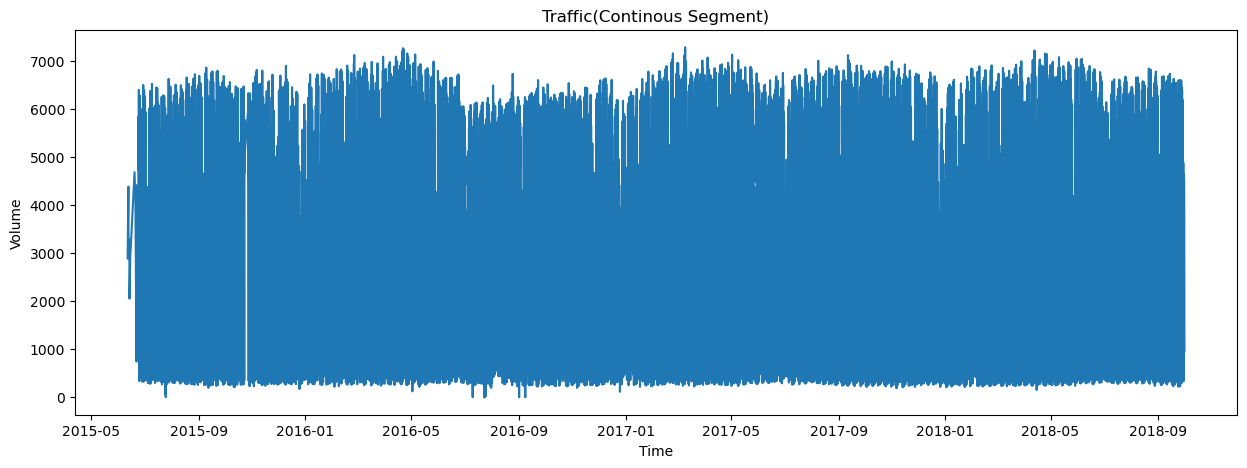

In [44]:
plt.figure(figsize =(15,5))
plt.plot(df['date_time'],df['traffic_volume'])
plt.title("Traffic(Continous Segment)")
plt.xlabel("Time")
plt.ylabel("Volume")
plt.show()

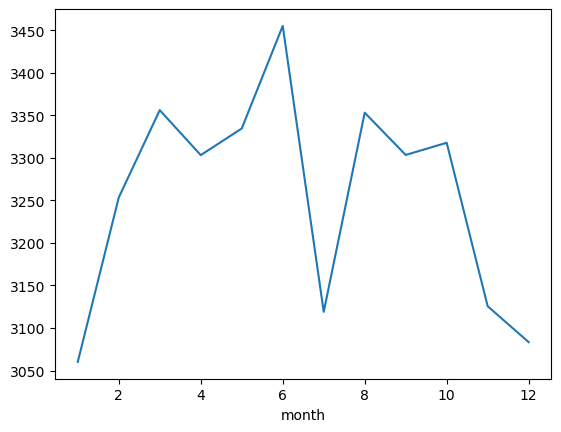

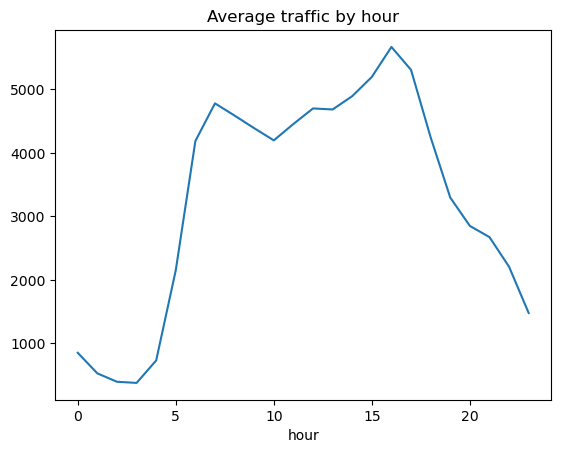

In [45]:
#better way to check seasonality monthly average
df['month'] = df['date_time'].dt.month
df.groupby('month')['traffic_volume'].mean().plot()
plt.show()
# seasonality hours
df['hour']=df['date_time'].dt.hour
df.groupby('hour')['traffic_volume'].mean().plot()
plt.title("Average traffic by hour")
plt.show()

In [46]:
# Trend :no strong trend visible
# Variance : Approximately constant
# Seasonality : Strong daily seasonality(rush -hour pattern)
# mean is almost same level and variance roughly constant and daily seasonality can be observed so mostly it is stationary
# let's perform using adf test

## 3. Stationarity Assessment
The stationarity of the traffic volume series is evaluated using the Augmented Dickey Fuller Test. A stationary series is required before fitting autoregressive models.

In [47]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['traffic_volume'])
print("ADF Statistic:",result[0])
print("p-value:", result[1])
print("critical values:")
for key,value in result[4].items():
    print(key,":",value)

ADF Statistic: -22.026510644270665
p-value: 0.0
critical values:
1% : -3.430553327383553
5% : -2.861629865429566
10% : -2.566817832587168


## 4. AR(2) Model Development
The ACF and PACF plots are analyzed to identify an appropriate autoregressive order. Based on the observations, an AR(2) is selected. The model parameters are first estimated using the Yule-Walker equations and then verified using Maximum Likelihood Estimation(MLE) to obtain a statistically reliable model.

<Figure size 1200x400 with 0 Axes>

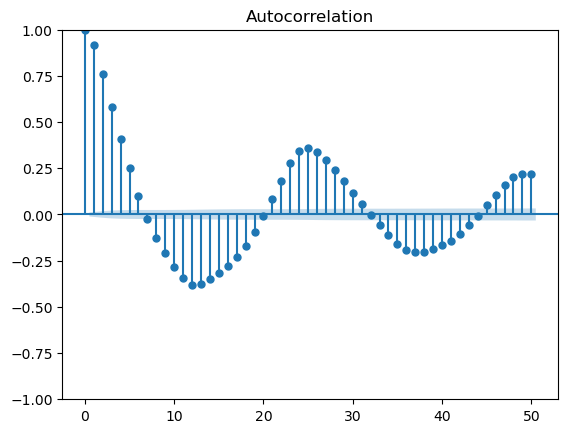

<Figure size 1200x400 with 0 Axes>

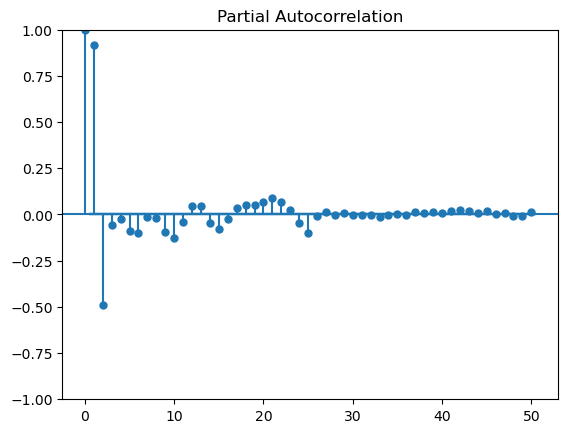

In [48]:
#model
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
plt.figure(figsize=(12,4))
plot_acf(df['traffic_volume'],lags = 50)
plt.show()
plt.figure(figsize = (12,4))
plot_pacf(df['traffic_volume'],lags =50)
plt.show()

In [21]:
# The ACF tails off gradually, suggesting an AR model. The PACF cuts off after lag 2, indicating an AR(2) model.
# estimating phi 1, 2 using yule walker 
from statsmodels.tsa.stattools import acf
rho = acf(df['traffic_volume'],nlags =2)
print("rho1 =",rho[1])
print("rho2 =",rho[2])
from statsmodels.regression.linear_model import yule_walker
phi,sigma = yule_walker(df['traffic_volume'],order =2)
print("phi1 =" ,phi[0])
print("phi 2=",phi[1])
print("sigma =",sigma)

rho1 = 0.9160570858928931
rho2 = 0.7606343043549676
phi1 = 1.3635166695812555
phi 2= -0.4884163513071189
sigma = 690.579767343263


In [49]:
#using MLE we will find whether AR(2) provides adequate fit or not
from statsmodels.tsa.ar_model import AutoReg
model = AutoReg(df['traffic_volume'],lags =2)
result = model.fit()
print(result.params)
print(result.llf)   # log likelihood
print(result.aic)
print(result.bic)
print(result.summary())

const                406.813217
traffic_volume.L1      1.363522
traffic_volume.L2     -0.488418
dtype: float64
-256310.23915634444
512628.4783126889
512661.99893836747
                            AutoReg Model Results                             
Dep. Variable:         traffic_volume   No. Observations:                32216
Model:                     AutoReg(2)   Log Likelihood             -256310.239
Method:               Conditional MLE   S.D. of innovations            690.591
Date:                Thu, 02 Jul 2026   AIC                         512628.478
Time:                        11:14:18   BIC                         512661.999
Sample:                             2   HQIC                        512639.197
                                32216                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               406.8132

In [50]:
phi1 = 1.363522
phi2 = -0.488418
#coefficients of 1-phi1*z-phi2*z^2 =0
roots = np.roots([phi2,phi1,-1])
print("Roots:")
print(roots)
print("\n Modulus:")
print(np.abs(roots))
if np.all(np.abs(roots)>1):
    print("\n Causal and Stationary")
else:
    print("\n Not Causal and Not stationary")
    

Roots:
[1.3958556+0.31466448j 1.3958556-0.31466448j]

 Modulus:
[1.43088315 1.43088315]

 Causal and Stationary


## 5. Residual Analysis
After fitting the AR(2) model, the residuals are analysed to evaluate model adequacy. The residual plots, histogram, residual ACF, and Ljung-Box test are used to determine whether the remaining errors behave like whitenoise. If significant autocorrelation remains in the residuals, the AR(2) model is considered inadequate, motivating the use of a more flexible ARMA model

In [51]:
residuals = result.resid
print(residuals.head())
print(residuals.describe())

15973   -1874.465434
15974     811.356001
15975    -353.419089
15976    -889.629748
15977    1190.393145
dtype: float64
count    3.221400e+04
mean    -4.079090e-13
std      6.906015e+02
min     -6.228843e+03
25%     -3.667448e+02
50%     -4.804505e+01
75%      2.941237e+02
max      6.325020e+03
dtype: float64


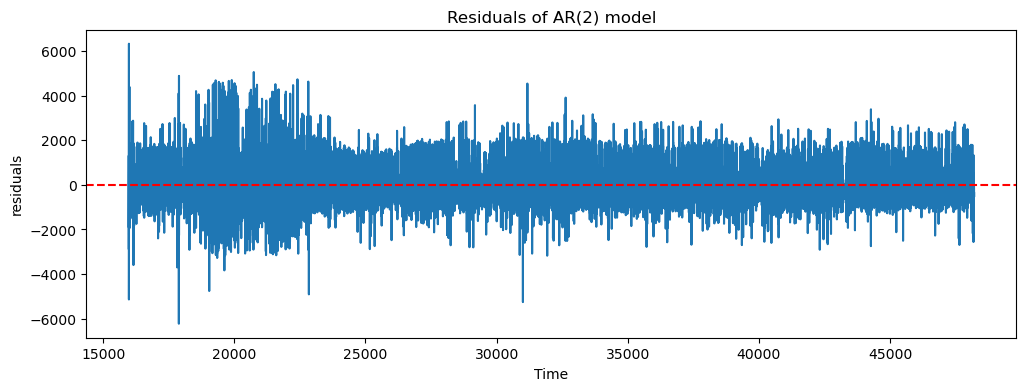

In [52]:
#Residuals plot
import matplotlib.pyplot as plt
plt.figure(figsize =(12,4))
plt.plot(residuals)
plt.axhline(y=0,color ='red',linestyle ='--')
plt.title("Residuals of AR(2) model")
plt.xlabel("Time")
plt.ylabel("residuals")
plt.show()
          

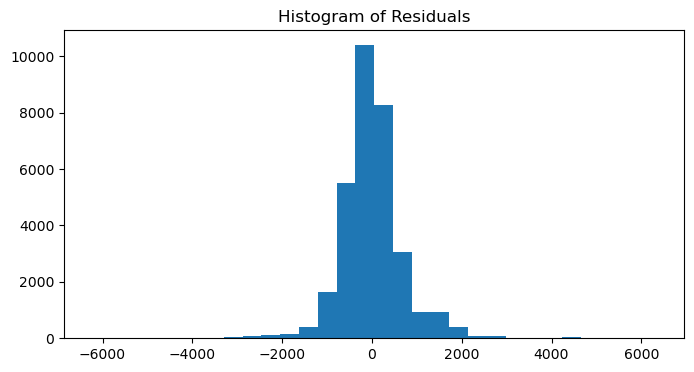

In [53]:
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=30)
plt.title("Histogram of Residuals")
plt.show()

<Figure size 1000x400 with 0 Axes>

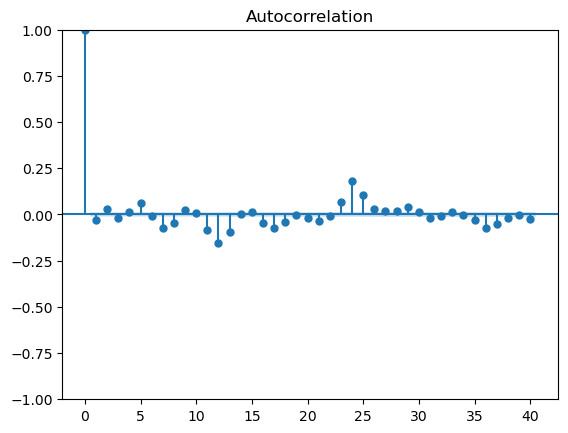

In [54]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,4))
plot_acf(residuals, lags=40)
plt.show()

In [55]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(
    residuals,
    lags=[10,20,24,30],
    return_df=True
)

print(lb_test)

        lb_stat     lb_pvalue
10   466.593619  6.017069e-94
20  2057.026543  0.000000e+00
24  3308.479347  0.000000e+00
30  3784.149893  0.000000e+00


The AR(2) model was found to be stationary and causal based on the root analysis. However, 
residual diagnostics revealed significant autocorrelation remaining in the residuals.
The Ljung–Box test strongly rejected the null hypothesis of white-noise residuals (p-value < 0.05 at all examined lags). 
Therefore, the AR(2) model is not adequate for fully capturing the dependence structure of the traffic volume series

Since the AR(2) model failed the residual diagnostics, we proceed to ARMA model selection. Rather than manually estimating multiple ARMA models, a grid search approach is adopted. For each candidate ARMA(p,q) model, the parameters are estimated using Maximum Likelihood Estimation (MLE). The Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC) are computed for model comparison. The model with the lowest AIC/BIC is selected as the best candidate. Finally, residual diagnostics, including ACF plots and the Ljung–Box test, are performed to verify whether the selected model adequately captures the dependence structure of the series.

In [56]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

In [57]:
print(len(df))

32216


In [58]:

results =[]

best_aic = float('inf')

best_bic = float('inf')

best_aic_order = None

best_bic_order = None

for p in range(3):

    for q in range(3):

        if p==0 and q==0:#white noise skip it

            continue

        print(f"Trying ARMA {p},{q}")

        try:

            model = ARIMA(df['traffic_volume'],order = (p,0,q))

            fit = model.fit()

            aic = fit.aic

            bic = fit.bic

            results.append([p,q,aic,bic])

            print(f"AIC ={aic:.2f},BIC = {bic : .2f}")



            if aic <best_aic:

                best_aic = aic

                best_aic_order =(p,q)

            if bic <best_bic:

                best_bic = bic

                best_bic_order =(p,q)

        except Exception as e:

           print(f"ARMA({p},{q}) failed:",e)

print("\nBest AIC Model:", best_aic_order)

print("Best AIC:", best_aic)



print("\nBest BIC Model:", best_bic_order)

print("Best BIC:", best_bic)

Trying ARMA 0,1
AIC =547489.79,BIC =  547514.93
Trying ARMA 0,2
AIC =529927.29,BIC =  529960.81
Trying ARMA 1,0
AIC =521442.12,BIC =  521467.26
Trying ARMA 1,1
AIC =514941.43,BIC =  514974.95
Trying ARMA 1,2
AIC =513263.28,BIC =  513305.18
Trying ARMA 2,0
AIC =512664.13,BIC =  512697.65
Trying ARMA 2,1
AIC =512540.32,BIC =  512582.22
Trying ARMA 2,2
AIC =512119.42,BIC =  512169.70

Best AIC Model: (2, 2)
Best AIC: 512119.41773607035

Best BIC Model: (2, 2)
Best BIC: 512169.69904708554


 Grid search was performed over candidate ARMA(p,q) models.
 Parameters were estimated using Maximum Likelihood Estimation (MLE).
 Models were compared using AIC and BIC.

 Both AIC and BIC selected ARMA(2,2) as the optimal model.

 Therefore, ARMA(2,2) is fitted on the complete traffic volume
 series and subjected to residual diagnostics.

In [59]:
#cell fit
best_model = ARIMA(df['traffic_volume'],order =(2,0,2)).fit() 
print(best_model.summary())

                               SARIMAX Results                                
Dep. Variable:         traffic_volume   No. Observations:                32216
Model:                 ARIMA(2, 0, 2)   Log Likelihood             -256053.709
Date:                Thu, 02 Jul 2026   AIC                         512119.418
Time:                        11:19:38   BIC                         512169.699
Sample:                             0   HQIC                        512135.497
                              - 32216                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       3257.8145     22.319    145.964      0.000    3214.069    3301.559
ar.L1          1.7739      0.006    275.847      0.000       1.761       1.787
ar.L2         -0.8335      0.005   -156.705      0.0

count    32216.000000
mean        -0.051293
std        684.757030
min      -6194.488010
25%       -373.830824
50%        -74.395225
75%        294.523787
max       6331.380627
dtype: float64


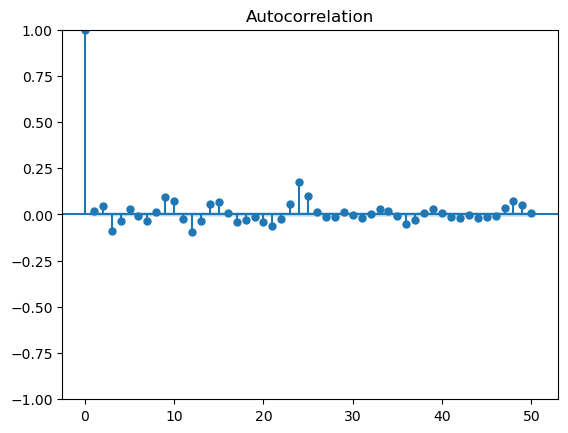

In [60]:
residuals = best_model.resid
print(residuals.describe())
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals,lags =50)
plt.show()

In [61]:
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals,lags=[10,20,24,30],return_df = True)
print(lb_test)

        lb_stat      lb_pvalue
10   894.002751  1.243622e-185
20  1669.331619   0.000000e+00
24  2894.364748   0.000000e+00
30  3227.981420   0.000000e+00


### ARMA(2,2) Conclusion

ARMA(2,2) was selected as the best model based on AIC and BIC. However, the Ljung–Box test showed that the residuals are still autocorrelated (p-value < 0.05), indicating that the model is inadequate.

Since the series is already stationary, moving to a non-seasonal ARIMA model is not necessary. The remaining autocorrelation around lag 24 suggests daily seasonality, motivating the use of a SARIMA model with seasonal period \(s = 24\).